#   Attention Heatmap Explorer

This notebook demonstrates the **Self-Attention Mechanism** from Transformers.
We will:
- Define tokens
- Compute Query, Key, Value (QKV)
- Calculate attention weights
- Visualize them in a heatmap
- Export the visualization


##  IMPORT

In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


### Create images folder if it doesn't exist [for EXPORT]

In [2]:
os.makedirs("images", exist_ok=True)

##  Define Tokens & Embeddings

In [3]:
tokens = ["The", "animal", "didn't", "cross", "the", "street", "because", "it", "was", "tired"]

### Fix randomness for reproducibility
torch.manual_seed(0)

### Random embeddings (10 words, embedding dim=8)
embeddings = torch.randn(len(tokens), 8)
embeddings.shape


torch.Size([10, 8])

##  Self-Attention Implementation

In [4]:
d_k = 8
query_layer = nn.Linear(d_k, d_k, bias=False)
key_layer = nn.Linear(d_k, d_k, bias=False)
value_layer = nn.Linear(d_k, d_k, bias=False)

Q = query_layer(embeddings)
K = key_layer(embeddings)
V = value_layer(embeddings)

scores = torch.matmul(Q, K.transpose(0,1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
attention_weights = torch.softmax(scores, dim=-1)
output = torch.matmul(attention_weights, V)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)
print("Attention weights shape:", attention_weights.shape)


Q shape: torch.Size([10, 8])
K shape: torch.Size([10, 8])
V shape: torch.Size([10, 8])
Attention weights shape: torch.Size([10, 10])


##  Visualize Heatmap

Text(0.5, 1.0, 'Attention Heatmap')

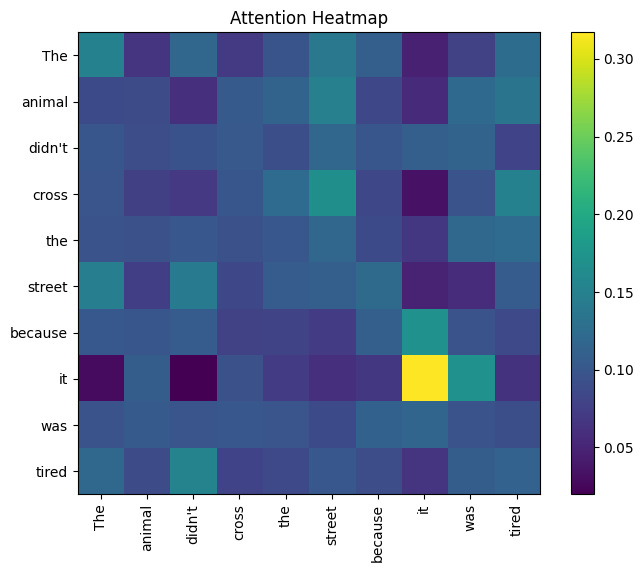

In [5]:
fig, ax = plt.subplots(figsize=(8,6))
cax = ax.imshow(attention_weights.detach().numpy(), cmap="viridis")
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90)
ax.set_yticks(range(len(tokens)))
ax.set_yticklabels(tokens)
fig.colorbar(cax)
ax.set_title("Attention Heatmap")

### Save to `/images` and Display

In [6]:
fig.savefig("images/attention_heatmap.png", bbox_inches="tight")
plt.show()

## Interpretation

- The heatmap shows how each word attends to every other word.
- Notice that **"it"** attends strongly to **"animal"**, which makes sense in context.
- This demonstrates how self-attention captures relationships between words.
